In [ ]:
#import of used libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score,mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix
import datetime #easier to process datetime format as a variable
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_squared_error, mean_absolute_error
from xgboost import XGBRegressor,DMatrix
import warnings
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA
import numpy as np
import itertools
from statsmodels.tsa.arima.model import ARIMA

# Predicting EUR/USD 


### Descriptive analysis of your data

First, we chose a dataset from Kaggle. (https://www.kaggle.com/datasets/chandrimad31/eurusd-forex-trading-data-20032021)

This dataset consists of data collected every four hours from the EUR/USD exchange rate. It contains the date, opening price, closing price, highest price, lowest price, and volume. 

In [2]:
# download csv file locally

data = pd.read_csv("Data_EURUSD_4h.csv")
data.info()
data.shape




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28860 entries, 0 to 28859
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Gmt time  28860 non-null  object 
 1   open      28860 non-null  float64
 2   high      28860 non-null  float64
 3   low       28860 non-null  float64
 4   close     28860 non-null  float64
 5   volume    28860 non-null  float64
dtypes: float64(5), object(1)
memory usage: 1.3+ MB


(28860, 6)

In [3]:
data= data.iloc[::12, :].copy()
data.reset_index(drop=True, inplace=True)


In [4]:
data.head()

,Gmt time,open,high,low,close,volume
0,04.05.2003 21:00:00.000,1.12354,1.12354,1.12166,1.12274,95533.0976
1,06.05.2003 21:00:00.000,1.14367,1.14448,1.14170,1.14274,93442.5000
2,08.05.2003 21:00:00.000,1.15002,1.15364,1.14732,1.15164,95166.0000
3,12.05.2003 21:00:00.000,1.15427,1.15751,1.15101,1.15150,95618.9004
4,14.05.2003 21:00:00.000,1.14983,1.14988,1.14681,1.14713,92479.4004


In [5]:
# show if there is any missing value
data.isnull().sum()

Gmt time    0
open        0
high        0
low         0
close       0
volume      0
dtype: int64

In [6]:
# show if a value is zero
(data == 0).sum()

Gmt time    0
open        0
high        0
low         0
close       0
volume      4
dtype: int64

In [7]:
data[data['volume'] == 0]

,Gmt time,open,high,low,close,volume
10,31.05.2003 21:00:00.000,1.17691,1.17825,1.17691,1.17825,0.0
914,30.04.2010 21:00:00.000,1.32936,1.32936,1.32910,1.32910,0.0
1382,30.11.2013 22:00:00.000,1.35917,1.35920,1.35917,1.35920,0.0
1404,31.01.2014 22:00:00.000,1.34898,1.34900,1.34898,1.34900,0.0


In [8]:
# drop column Gmt time
data['Gmt time'] = pd.to_datetime(data['Gmt time'],format = "%d.%m.%Y %H:%M:%S.%f")

In [9]:
mean_volume = data['volume'].mean()

print("Mean volume (excluding zeros):", mean_volume)

Mean volume (excluding zeros): 84452.98963983366


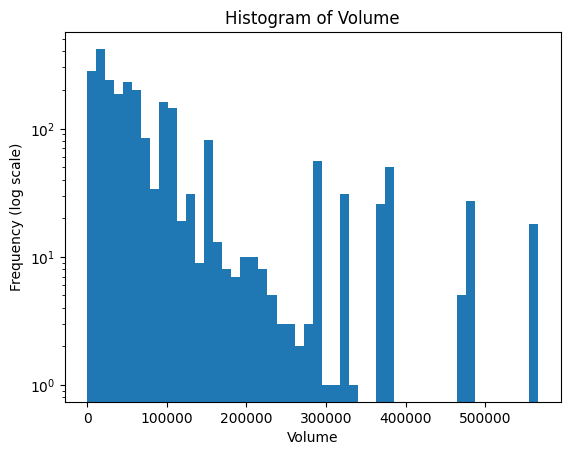

In [10]:
# histogram of volume
import matplotlib.pyplot as plt
plt.hist(data['volume'], bins=50)
plt.yscale('log')
plt.xlabel('Volume')
plt.ylabel('Frequency (log scale)')
plt.title('Histogram of Volume')
plt.show()

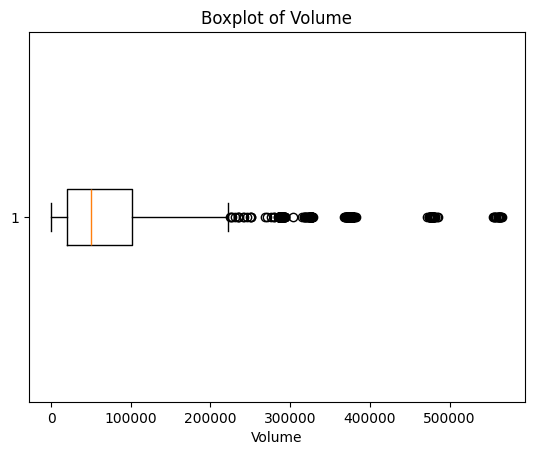

In [11]:
# boxplot of volume
plt.boxplot(data['volume'], vert=False)
plt.xlabel('Volume')
plt.title('Boxplot of Volume')
plt.show()


with the different plot, we can concluded that 0 is not an aberrant value. 

In [12]:
data.describe()

,Gmt time,open,high,low,close,volume
count,2405,2405.00000,2405.000000,2405.000000,2405.000000,2405.000000
mean,2012-07-18 22:14:52.141372160,1.25443,1.256497,1.252416,1.254484,84452.989640
min,2003-05-04 21:00:00,1.03936,1.040970,1.039340,1.040430,0.000000
25%,2007-12-09 22:00:00,1.15448,1.157060,1.153670,1.154230,19336.349600
50%,2012-07-13 13:00:00,1.24148,1.243820,1.238680,1.241500,49626.460000
75%,2017-02-27 02:00:00,1.33930,1.341430,1.336750,1.338650,101106.199200
max,2021-10-13 21:00:00,1.59245,1.593540,1.589980,1.591270,565936.890700
std,NaN,0.11951,0.119731,0.119187,0.119458,105049.085244


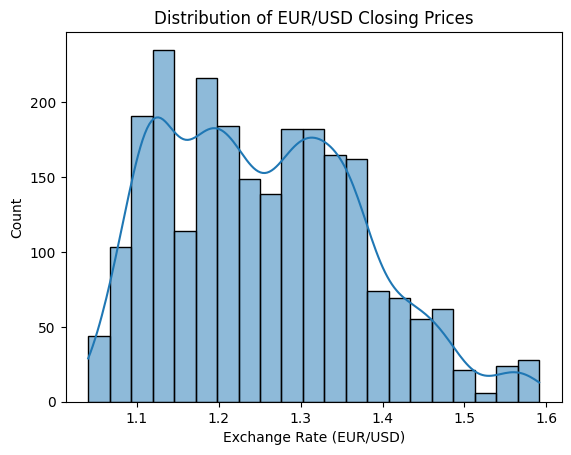

In [13]:
# Histogram of the distrubution of Euro and Dollar exchange rates

sns.histplot(data['close'], kde=True)
plt.title("Distribution of EUR/USD Closing Prices")
plt.xlabel("Exchange Rate (EUR/USD)")
plt.show()

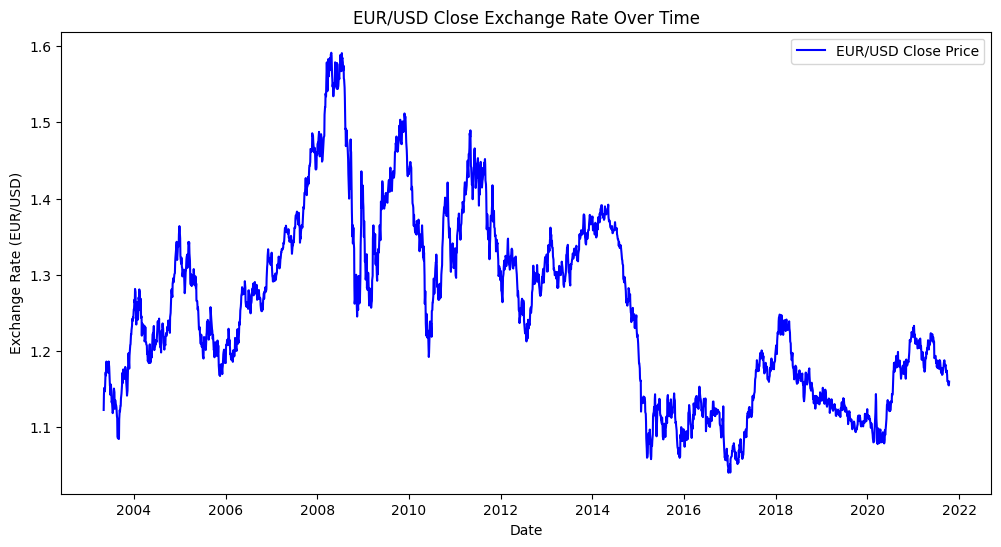

In [14]:
# Plot of close price over time 
plt.figure(figsize=(12,6))
plt.plot(data['Gmt time'], data['close'], label='EUR/USD Close Price', color='blue')
plt.title('EUR/USD Close Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (EUR/USD)')
plt.legend()
plt.show()

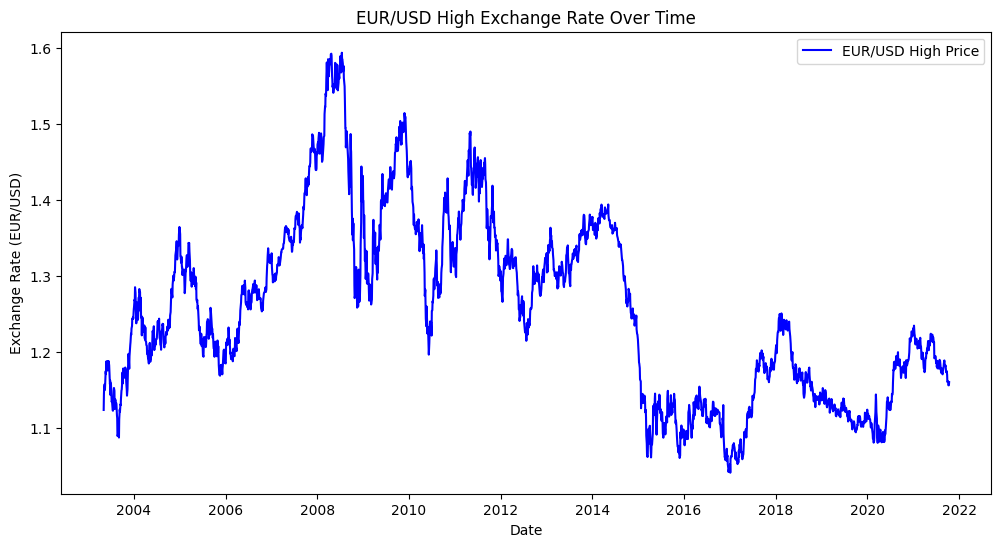

In [15]:
# Plot of highest price every 4H over time
plt.figure(figsize=(12,6))
plt.plot(data["Gmt time"], data['high'], label='EUR/USD High Price', color='blue')
plt.title('EUR/USD High Exchange Rate Over Time')
plt.xlabel("Date")
plt.ylabel('Exchange Rate (EUR/USD)')
plt.legend()
plt.show()

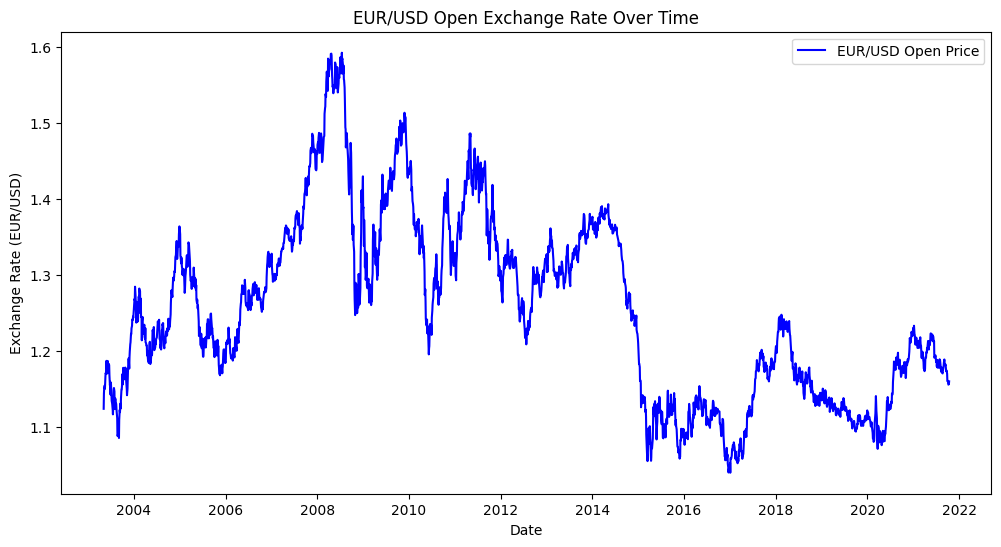

In [16]:
# Plot of open price overtime
plt.figure(figsize=(12,6))
plt.plot(data["Gmt time"], data['open'], label='EUR/USD Open Price', color='blue')
plt.title('EUR/USD Open Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (EUR/USD)')
plt.legend()
plt.show()

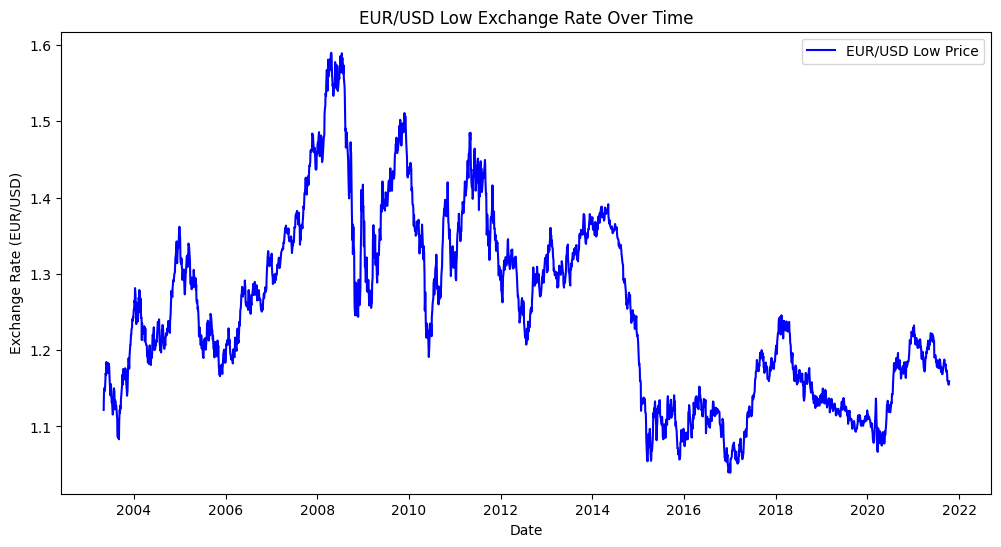

In [17]:
# Plot of Lowest price every 4H over time
plt.figure(figsize=(12,6))
plt.plot(data["Gmt time"], data['low'], label='EUR/USD Low Price', color='blue')
plt.title('EUR/USD Low Exchange Rate Over Time')
plt.xlabel('Date')
plt.ylabel('Exchange Rate (EUR/USD)')
plt.legend()
plt.show()

### Conclusion : Descriptive analysis of your data.
Our dataset contains historical exchange rates between Euro and US Dollar.
this dataset contains 28860 records with 6 features: Gmt time, Open, High, Low, Close, and Volume.
Remainder that the FX euro dollar is open 24 hours a day from Monday to Friday, so the data is recorded for every trading day. And without holidays.
we have seen that there are no missing values and the zero values are not problematic.

The plots show that there are no abberant values in the data. The trend is mostly continous and can be used for moving average forecast and pattern recognition.




### Implementation of basic linear regression models and treeclassifier

In this part we'll be trying to forecast the evolution of close price with basic models. Since time isn't really a usable feature we'll be introducing some pattern features like moving average and volatility that are used in Time Series Econometrics for this specific kind of time series to. The patterns are meant to help the model detect trends and forecast at an H+4 timeframe, we'll be specifically cautious to avoid data leakage when computing moving average.

In [18]:
# drop column Gmt time and create a copy
df = data.copy()

Several technical indicators were added to make the dataset richer and help the models perform better. Financial time series often contain patterns that are not visible in the raw price.

- Return: shows how much the price changes from one period to the next.
- MA5 & MA20: moving averages show short-term and medium-term trends in the market.
- Volatility: shows how much the price moves up and down.
- RSI: helps identify if the market is going up too fast (overbought) or down too fast (oversold).
- EMA12, EMA26 & MACD: show fast and slow trends and help detect changes in momentum.
- VMA5, VMA20 & Volume Ratio: give information about trading activity and unusual volume, which can signal future price moves.

Overall, these new features give useful information about trends, momentum, volatility, and volume. This helps machine learning models understand the market better.

In [19]:
# add some indicators to the dataframe
df['Return'] = df['close'].pct_change()

df['MA5'] = df['close'].rolling(5).mean()
df['MA20'] = df['close'].rolling(20).mean()

df['Volatility'] = df['Return'].rolling(10).std()

df['RSI'] = 100 - (100 / (1 + df['Return'].rolling(14).apply(lambda x: (x[x > 0].sum() / -x[x < 0].sum()) if -x[x < 0].sum() != 0 else 0)))

df["EMA12"] = df['close'].ewm(span=12, adjust=False).mean()
df["EMA26"] = df['close'].ewm(span=26, adjust=False).mean()
df["MACD"] = df["EMA12"] - df["EMA26"]

df["VMA5"] = df['volume'].rolling(5).mean()
df["VMA20"] = df['volume'].rolling(20).mean()
df["Volume_Ratio"] = df["VMA5"] / df["VMA20"]

Lagged values of the closing price were added so the model can keep some memory of past movements. Financial time series often depend on recent values, so using lagged features helps the model learn these time-based patterns.

In [20]:
# add lagged features
for lag in range(1, 6):  # 5 days of lag
    df[f'Lag_{lag}'] = df['close'].shift(lag)

In [21]:
# create target variable (for next close price)
df["Target"] = df["close"].shift(-1)

In [22]:
# clean dataset
df = df.dropna()

print("\nIndicator created :")
print(df.head())
print("\nNb de NaN restants par colonne :")
print(df.isna().sum())


Indicator created :
              Gmt time     open     high      low    close       volume  \
19 2003-06-25 17:00:00  1.15919  1.16215  1.15173  1.15398  370251.2969   
20 2003-06-27 17:00:00  1.14237  1.14324  1.14074  1.14254  370356.6992   
21 2003-07-01 17:00:00  1.15790  1.15872  1.15549  1.15608  373451.0000   
22 2003-07-03 17:00:00  1.15018  1.15067  1.14738  1.14945  379440.3985   
23 2003-07-07 17:00:00  1.13390  1.13418  1.13132  1.13252  376872.7969   

      Return       MA5      MA20  Volatility  ...      MACD          VMA5  \
19 -0.000269  1.169194  1.165625    0.008060  ...  0.008501  374524.04222   
20 -0.009914  1.160442  1.166615    0.008282  ...  0.005918  374347.62114   
21  0.011851  1.155784  1.167282    0.009513  ...  0.004907  373743.28050   
22 -0.005735  1.151268  1.167172    0.008878  ...  0.003530  373938.65862   
23 -0.014729  1.146914  1.166224    0.009366  ...  0.001060  374074.43830   

            VMA20  Volume_Ratio    Lag_1    Lag_2    Lag_3    Lag

In [23]:
#feature and target variable
X = df.drop(columns=["Target", "Return", "open", "high", "low","Gmt time"])
y = df["Target"]

In [24]:
# split train, test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)
print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (1908, 17)
Test shape: (477, 17)


In [25]:
# scale the data
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [26]:
# models to test
models = {
    "Linear Regression": LinearRegression(),
    "Random Forest": RandomForestRegressor(n_estimators=200, random_state=42),
    "Gradient Boosting": GradientBoostingRegressor(random_state=42),
    "Decision Tree": DecisionTreeRegressor(),
    "SVR": SVR(kernel="rbf", C=1.0)
}
results = {}

In [27]:
# evaluate each model
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)

    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)

    results[name] = [mae, rmse, r2]
    print(f"{name} = MAE: {mae:.4f}, RMSE: {rmse:.4f}, R2: {r2:.4f}")

Linear Regression = MAE: 0.0052, RMSE: 0.0066, R2: 0.9756
Random Forest = MAE: 0.0060, RMSE: 0.0074, R2: 0.9694
Gradient Boosting = MAE: 0.0057, RMSE: 0.0073, R2: 0.9707
Decision Tree = MAE: 0.0105, RMSE: 0.0132, R2: 0.9036
SVR = MAE: 0.0315, RMSE: 0.0364, R2: 0.2633


In [28]:
# summarize results
results_df = pd.DataFrame(results, index=["MAE", "RMSE", "R2"]).T
print("\nPerformance Summary:")
print(results_df)


Performance Summary:
                        MAE      RMSE        R2
Linear Regression  0.005238  0.006625  0.975562
Random Forest      0.005960  0.007411  0.969420
Gradient Boosting  0.005657  0.007257  0.970680
Decision Tree      0.010505  0.013161  0.903565
SVR                0.031513  0.036377  0.263283


In [29]:
# identify the best model based on RMSE
best_model_name = results_df["RMSE"].idxmin()
print("\nBest model (RMSE) : ", best_model_name)


Best model (RMSE) :  Linear Regression


We notice that basic models aren't suited for time series we'll need implement more complex models later like ARIMA, XGBoost that are better at forecasting time series and are known to be reliable on classic ForEx trading pairs.

### Xgboost Pipeline

 
 - import 
 - visualisation
 - scaling 
 - xgboost setup
 - hyperparametter fitting



In [30]:
#import dataframe and convert datetime

df['Gmt time'] = pd.to_datetime(df['Gmt time'],format = "%d.%m.%Y %H:%M:%S.%f")
df.head()

,Gmt time,open,high,low,close,volume,Return,MA5,MA20,Volatility,...,MACD,VMA5,VMA20,Volume_Ratio,Lag_1,Lag_2,Lag_3,Lag_4,Lag_5,Target
19,2003-06-25 17:00:00,1.15919,1.16215,1.15173,1.15398,370251.2969,-0.000269,1.169194,1.165625,0.008060,...,0.008501,374524.04222,215865.786045,1.734986,1.15429,1.17203,1.17937,1.18630,1.17421,1.14254
20,2003-06-27 17:00:00,1.14237,1.14324,1.14074,1.14254,370356.6992,-0.009914,1.160442,1.166615,0.008282,...,0.005918,374347.62114,229606.966125,1.630384,1.15398,1.15429,1.17203,1.17937,1.18630,1.15608
21,2003-07-01 17:00:00,1.15790,1.15872,1.15549,1.15608,373451.0000,0.011851,1.155784,1.167282,0.009513,...,0.004907,373743.28050,243607.391125,1.534203,1.14254,1.15398,1.15429,1.17203,1.17937,1.14945
22,2003-07-03 17:00:00,1.15018,1.15067,1.14738,1.14945,379440.3985,-0.005735,1.151268,1.167172,0.008878,...,0.003530,373938.65862,257821.111050,1.450380,1.15608,1.14254,1.15398,1.15429,1.17203,1.13252
23,2003-07-07 17:00:00,1.13390,1.13418,1.13132,1.13252,376872.7969,-0.014729,1.146914,1.166224,0.009366,...,0.001060,374074.43830,271883.805875,1.375861,1.14945,1.15608,1.14254,1.15398,1.15429,1.13481


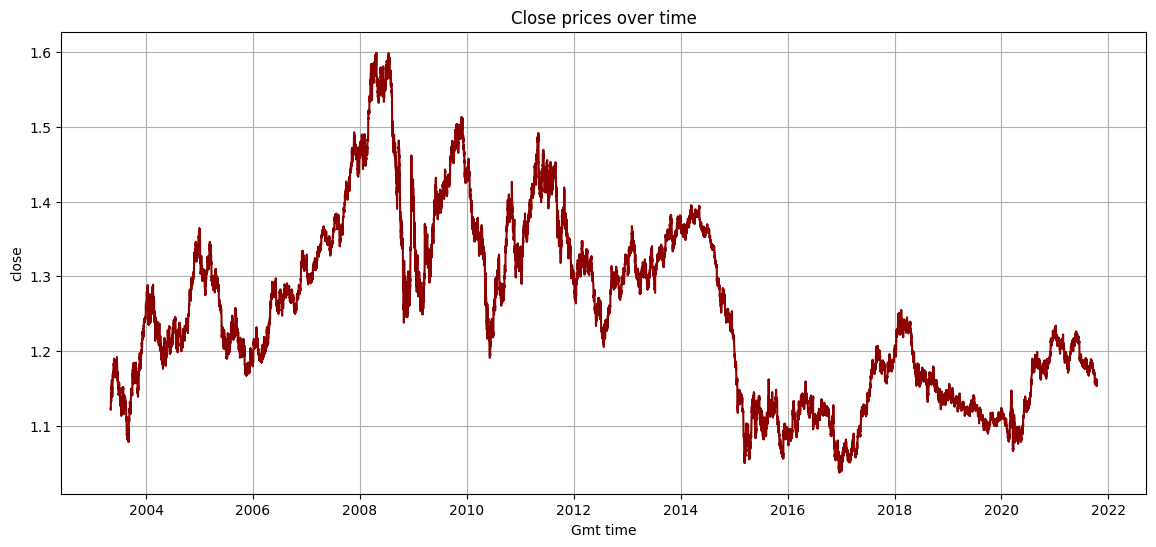

In [56]:
plt.figure(figsize=(14, 6))

plt.plot(df['Gmt time'], df['close'], color='darkred')

plt.title("Close prices over time")
plt.xlabel("Gmt time")
plt.ylabel("close")
plt.grid(True)
plt.show()

In [32]:
# data augmentation for pattern features and recognitions

df_upgrade = pd.DataFrame()
df_upgrade["Time"] = df["Gmt time"]
df_upgrade["close"] = df["close"]
df_upgrade["volume"] = df["volume"]

#adding moving average
df_upgrade["MA_5"] = df_upgrade["close"].shift(1).rolling(5).mean()
df_upgrade["MA_50"] = df_upgrade["close"].shift(1).rolling(50).mean()
df_upgrade["MA_250"] = df_upgrade["close"].shift(1).rolling(250).mean()

#adding std that serves as volatility 
df_upgrade["std_5"] = df_upgrade["close"].shift(1).rolling(5).std()
df_upgrade["std_50"] = df_upgrade["close"].shift(1).rolling(50).std()
df_upgrade["std_250"] = df_upgrade["close"].shift(1).rolling(250).std()

#adding returns
df_upgrade["returns_1"] = ((df_upgrade["close"]-df_upgrade["close"].shift(1))/df_upgrade['close'].shift(1))
df_upgrade["returns_5"] = ((df_upgrade["close"]-df_upgrade["close"].shift(5))/df_upgrade['close'].shift(5))
df_upgrade["returns_50"] = ((df_upgrade["close"]-df_upgrade["close"].shift(50))/df_upgrade['close'].shift(50))
df_upgrade["returns_250"] = ((df_upgrade["close"]-df_upgrade["close"].shift(250))/df_upgrade['close'].shift(250))

#adding volatility
df_upgrade["volatility_5"]  = df_upgrade["returns_1"].shift(1).rolling(5).std()
df_upgrade["volatility_50"]  = df_upgrade["returns_1"].shift(1).rolling(50).std()
df_upgrade["volatility_250"] = df_upgrade["returns_1"].shift(1).rolling(250).std()


df_upgrade = df_upgrade.dropna(axis = 0).reset_index(drop = True)

df_upgrade.head(5)


,Time,close,volume,MA_5,MA_50,MA_250,std_5,std_50,std_250,returns_1,returns_5,returns_50,returns_250,volatility_5,volatility_50,volatility_250
0,2005-05-27 05:00:00,1.25350,102106.0996,1.261764,1.300618,1.232826,0.005566,0.020404,0.063667,-0.002975,-0.009748,-0.050976,0.097117,0.008301,0.007819,0.008728
1,2005-05-31 05:00:00,1.23865,101853.7012,1.259296,1.299271,1.233270,0.006023,0.021247,0.063421,-0.011847,-0.021495,-0.057581,0.071422,0.004316,0.007821,0.008706
2,2005-06-02 05:00:00,1.22833,100714.3984,1.253854,1.297758,1.233600,0.009750,0.022792,0.063232,-0.008332,-0.029425,-0.071220,0.068624,0.005926,0.007952,0.008710
3,2005-06-06 05:00:00,1.22840,103024.7012,1.246406,1.295874,1.233915,0.012420,0.024530,0.063007,0.000057,-0.020657,-0.062161,0.084661,0.005627,0.007942,0.008719
4,2005-06-08 05:00:00,1.23123,103622.6016,1.241224,1.294246,1.234299,0.013643,0.026229,0.062679,0.002304,-0.020688,-0.059649,0.084966,0.005871,0.007857,0.008667


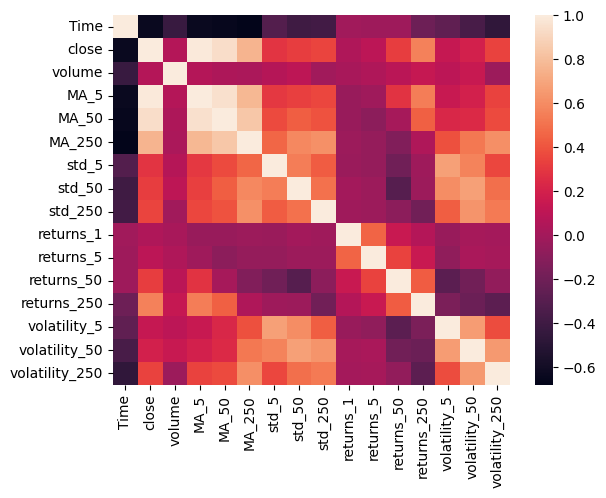

In [33]:
#Evaluate the correlation between the features 
sns.heatmap(df_upgrade.corr())
plt.show()

We can notice that the close price is mostly correlated with moving average as expected from a pretty stable exchange pair. We also notice that its slightly correlated to the returns and volatility.

In [34]:
#Split time periods for training 

rows = len(df_upgrade)
split_index = int(rows*0.8)

df_train = df_upgrade.iloc[:split_index]
df_validation = df_upgrade.iloc[split_index:]

X_train = df_train.drop(['close','Time'],axis = 'columns')
y_train = df_train['close']

X_test = df_validation.drop(['close','Time'],axis = 'columns')
y_test = df_validation['close']


In [35]:
#scaling

scaler = StandardScaler()

scaler.fit(X_train)

X_scaled_train = scaler.transform(X_train)
X_scaled_test = scaler.transform(X_test)

In [36]:
#XGBRegressor hyperparameters fitting

xgb = XGBRegressor(random_state = 0)

#most efficient data structure for the xgboost regressor
data = DMatrix(data = X_train, label = y_train)

param_grid = {
    'learning_rate': [0.01, 0.1, 0.2], 
    'n_estimators': [100, 250, 500],

    'max_depth': [3, 5, 7],  
    'min_child_weight': [1, 3, 5], 
    
    'subsample': [0.5, 0.7, 1.0], 
    'colsample_bytree': [0.5, 0.7, 1.0], 
}

grid_search = GridSearchCV(estimator = xgb,
                           param_grid = param_grid,
                           scoring = "neg_mean_squared_error",
                           cv =4,
                           verbose = 1,
                           n_jobs = -1)

grid_search.fit(X_train,y_train)

print("Best parameters for XGBRegressor:", grid_search.best_params_)
print("Best MSE for XGBRegressor:", -grid_search.best_score_)


Fitting 4 folds for each of 729 candidates, totalling 2916 fits
Best parameters for XGBRegressor: {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'min_child_weight': 3, 'n_estimators': 250, 'subsample': 0.5}
Best MSE for XGBRegressor: 0.00043088692872232334


In [37]:
xgb_best = grid_search.best_estimator_

xgb_best.fit(X_train,y_train)

y_pred = xgb_best.predict(X_test)

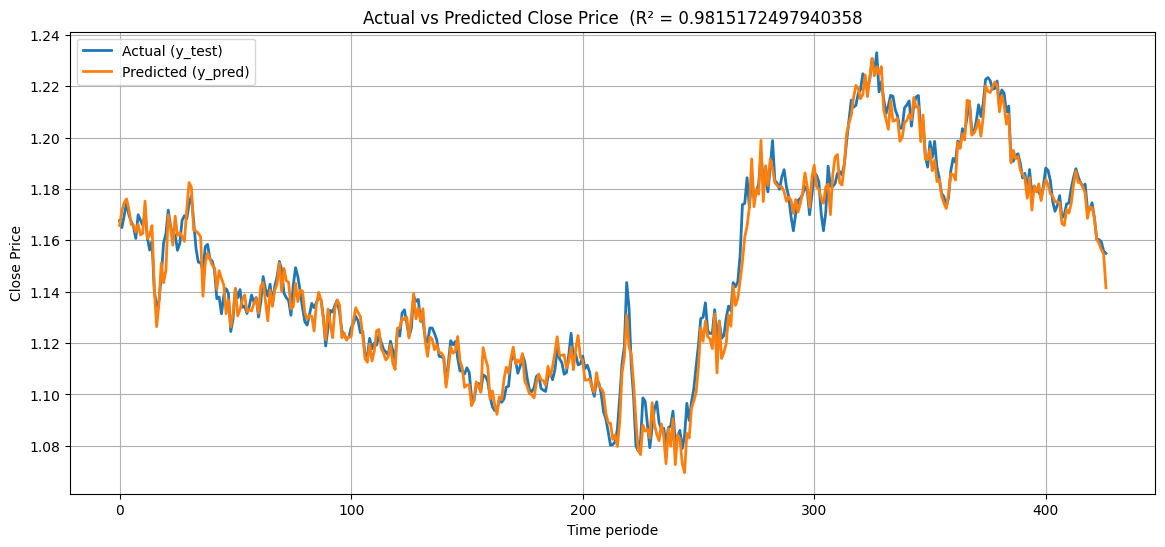

In [38]:
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(14,6))

plt.plot(y_test.values, label="Actual (y_test)", linewidth=2)
plt.plot(y_pred, label="Predicted (y_pred)", linewidth=2)

plt.title("Actual vs Predicted Close Price  (R² = {}".format(r2))
plt.xlabel("Time periode")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)



We noticed afterward that there may be some data leakage 


In [39]:
#shift the target by one time period to predict indeed H+4 instead of allowing the model to just reverse engineer the close price from the leaking moving average


df_upgrade["target"] = df_upgrade["close"].shift(-1)
df_upgrade = df_upgrade.dropna().reset_index(drop=True)

X = df_upgrade.drop(["Time", "close", "target"], axis=1)
y = df_upgrade["target"]

rows = len(df_upgrade)
split_index = int(rows * 0.8)

X_train = X.iloc[:split_index]
y_train = y.iloc[:split_index]

X_test  = X.iloc[split_index:]
y_test  = y.iloc[split_index:]



In [40]:
scaler = StandardScaler()

scaler.fit(X_train)

X_scaled_train = scaler.transform(X_train)
X_scaled_test = scaler.transform(X_test)

In [41]:
xgb = XGBRegressor(random_state = 0)

#most efficient data structure for the xgboost regressor
data = DMatrix(data = X_train, label = y_train)

param_grid = {
    'learning_rate': [0.01, 0.1, 0.2], 
    'n_estimators': [100, 250, 500],

    'max_depth': [3, 5, 7],  
    'min_child_weight': [1, 3, 5], 
    
    'subsample': [0.5, 0.7, 1.0], 
    'colsample_bytree': [0.5, 0.7, 1.0], 
}
grid_search = GridSearchCV(estimator = xgb,
                           param_grid = param_grid,
                           scoring = "neg_mean_squared_error",
                           cv =4,
                           verbose = 1,
                           n_jobs = -1)

grid_search.fit(X_train,y_train)

print("Best parameters for XGBRegressor:", grid_search.best_params_)
print("Best MSE for XGBRegressor:", -grid_search.best_score_)


Fitting 4 folds for each of 729 candidates, totalling 2916 fits
Best parameters for XGBRegressor: {'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 3, 'min_child_weight': 5, 'n_estimators': 250, 'subsample': 1.0}
Best MSE for XGBRegressor: 0.0008531066341369593


In [42]:
xgb_best = grid_search.best_estimator_

xgb_best.fit(X_train,y_train)

y_pred = xgb_best.predict(X_test)

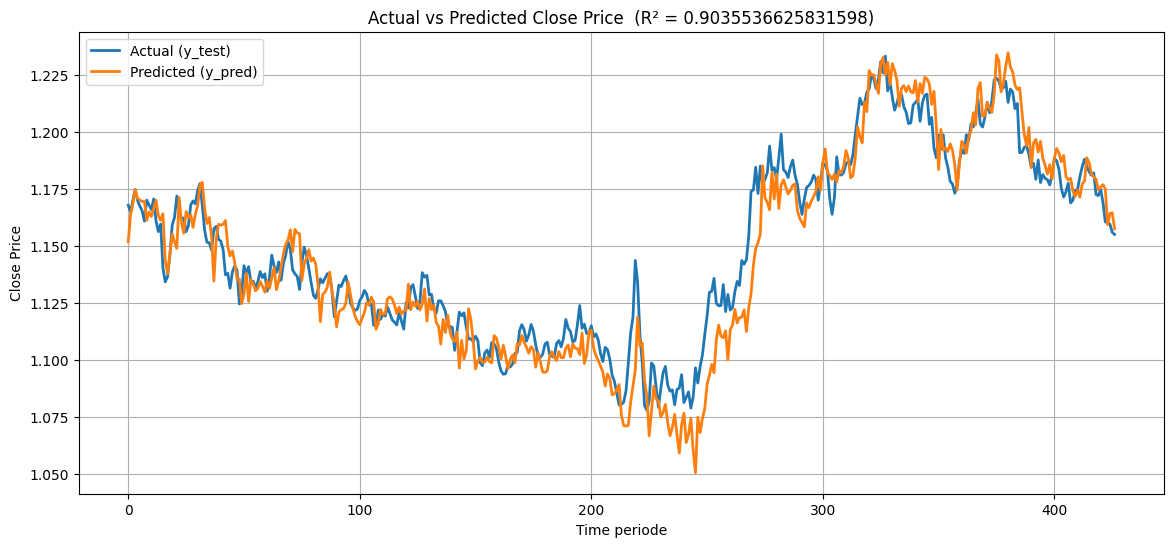

In [ ]:
r2 = r2_score(y_test, y_pred)

plt.figure(figsize=(14,6))

plt.plot(y_test.values, label="Actual (y_test)", linewidth=2)
plt.plot(y_pred, label="Predicted (y_pred)", linewidth=2)

plt.title("Actual vs Predicted Close Price  (R² = {})".format(r2))
plt.xlabel("Time period")
plt.ylabel("Close Price")
plt.legend()
plt.grid(True)


Removing the data leakage slightly reduced de R2 score but since we gave enough features the model is still able to perform correctly for this exchange rate since it's pretty stable.



### ARIMA

Autoregressive Integrated Moving Average (ARIMA) is one of the most widely used statistical models for forecasting univariate time series. It captures linear temporal dependencies through three parameters:

p: autoregressive order

d: differencing order (to achieve stationarity)

q: moving average order

ARIMA is particularly relevant for financial time series where short-term linear dependencies exist. It is often used as a baseline method before applying more advanced non-linear models.

Source : Google Scholar 
Forecasting the EUR/USD Exchange Rate Using ARIMA and Machine Learning Models (2024)
https://www.researchgate.net/publication/383543167_Forecasting_the_EURUSD_Exchange_Rate_Using_ARIMA_and_Machine_Learning_Models

In [44]:
# load data
df = pd.read_csv("Data_EURUSD_4h.csv")
df['Gmt time'] = pd.to_datetime(df['Gmt time'], format="%d.%m.%Y %H:%M:%S.%f")
series = df["close"]

In [45]:
# split data
test_size = 100
train, test = series[:-test_size], series[-test_size:]

In [46]:
# check stationarity (ADF test)
result = adfuller(train)
d = 0 if result[1] < 0.05 else 1
print("Selected differencing order d =", d)


Selected differencing order d = 1


In [47]:
# grid search for (p,d,q)
best_aic = np.inf
best_order = None
best_model = None

p_range = range(0, 6)
q_range = range(0, 6)


for p in p_range:
    for q in q_range:
        try:
            model = ARIMA(train, order=(p, d, q))
            model_fit = model.fit()
            if model_fit.aic < best_aic:
                best_aic = model_fit.aic
                best_order = (p, d, q)
                best_model = model_fit
        except:
            continue

print(f"\nBest ARIMA order: {best_order} with AIC = {best_aic}")

/Users/mamoune/Documents/machine_learning_S1/Project/Projet_ML/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/Users/mamoune/Documents/machine_learning_S1/Project/Projet_ML/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/Users/mamoune/Documents/machine_learning_S1/Project/Projet_ML/.venv/lib/python3.14/site-packages/statsmodels/base/model.py:607: ConvergenceWarning:

Maximum Likelihood optimization failed to converge. Check mle_retvals

/Users/mamoune/Documents/machine_learning_S1/Project/Projet_ML/.venv/lib/python3.14/site-packages/statsmodels/tsa/statespace/sarimax.py:966: UserWarning:

Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.

/Users/mamoune/Documents/machine_learning_S1/Project/Projet_ML/.venv/lib/python3.14/site


Best ARIMA order: (4, 1, 0) with AIC = -252510.53663538728


In [48]:
# summary
print(best_model.summary())

                               SARIMAX Results                                
Dep. Variable:                  close   No. Observations:                28760
Model:                 ARIMA(4, 1, 0)   Log Likelihood              126260.268
Date:                Fri, 05 Dec 2025   AIC                        -252510.537
Time:                        10:04:11   BIC                        -252469.203
Sample:                             0   HQIC                       -252497.248
                              - 28760                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0038      0.004      0.962      0.336      -0.004       0.012
ar.L2          0.0072      0.004      1.633      0.103      -0.001       0.016
ar.L3         -0.0185      0.005     -3.741      0.0

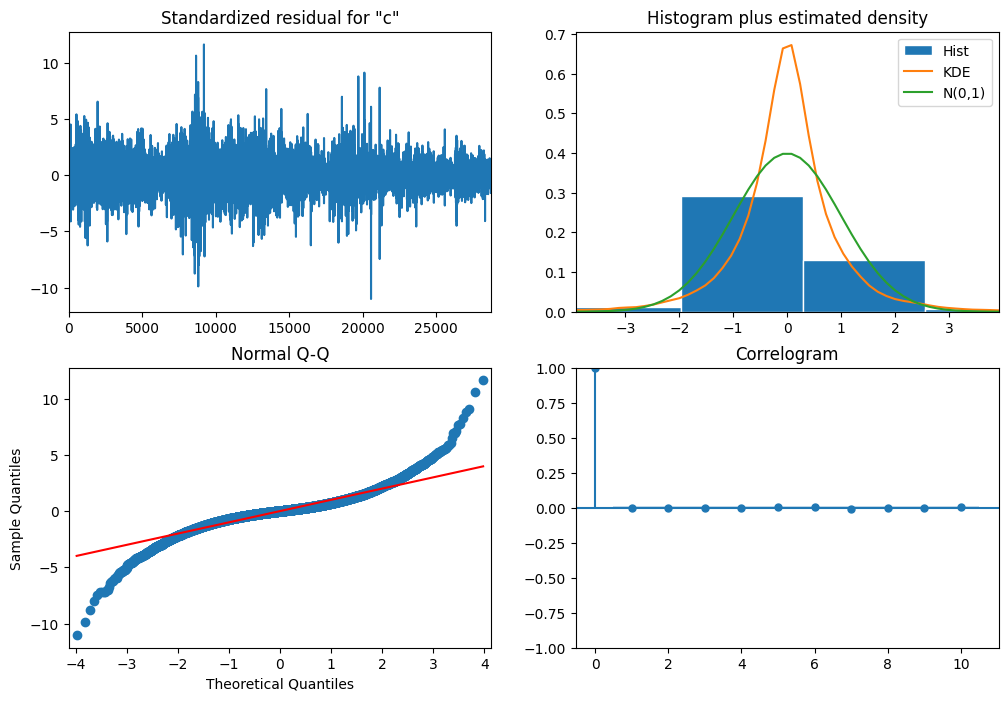

In [49]:
#diagnose the model
best_model.plot_diagnostics(figsize=(12,8))
plt.show()

In [50]:
#forecast
forecast = best_model.forecast(steps=test_size)

In [51]:
# evaluation
rmse = np.sqrt(mean_squared_error(test, forecast))
mae = mean_absolute_error(test, forecast)
r2 = r2_score(test, forecast)

print(f"RMSE : {rmse}")
print(f"MAE  : {mae}")
print(f"R²   : {r2}")

RMSE : 0.011509356343526194
MAE  : 0.010240396088222761
R²   : -2.6443153436942337


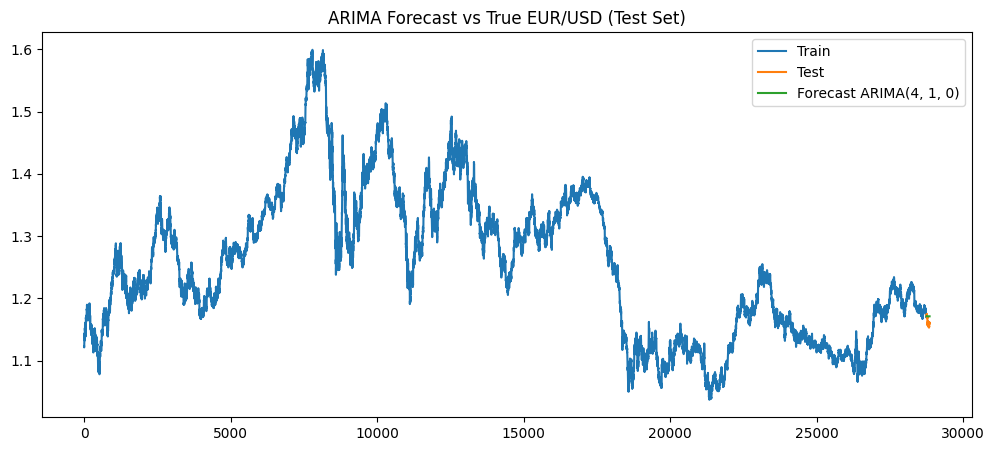

In [52]:
# visualisation
plt.figure(figsize=(12,5))
plt.plot(train, label="Train")
plt.plot(test, label="Test")
plt.plot(test.index, forecast, label=f"Forecast ARIMA{best_order}")
plt.legend()
plt.title("ARIMA Forecast vs True EUR/USD (Test Set)")
plt.show()

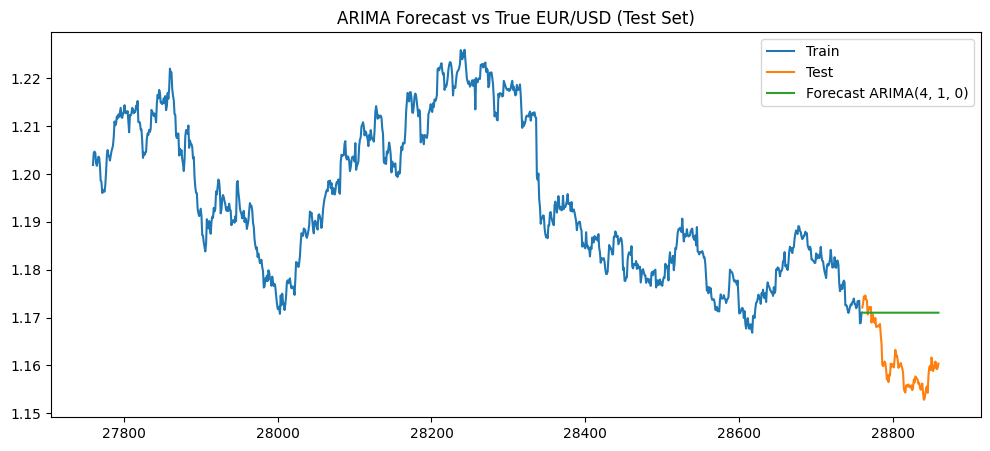

In [53]:
# we can zoom to see better
plt.figure(figsize=(12,5))
plt.plot(train[-1000:], label="Train")
plt.plot(test[-1000:], label="Test")
plt.plot(test.index[-1000:], forecast, label=f"Forecast ARIMA{best_order}")
plt.legend()
plt.title("ARIMA Forecast vs True EUR/USD (Test Set)")
plt.show()

We have a negative R² for the ARIMA, which means that it predicts less accurately than a simple constant average. Therefore, the model's forecasts deviate further from the actual values than if we simply used the average value of the series. This result is consistent with the highly noisy and unpredictable nature of intraday financial data such as EUR/USD. For this reason, the model produces a quasi-linear forecast that converges towards an average value. This behavior is typical of ARIMA models when the series has no exploitable trend or clear structure.

Note: we used technical features (MA, volatility, etc.), but we could have used more variables to improve the prediction results, such as fundamental data such as GDP, interest rates, unemployment, etc. 
